# Data Collection:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_excel("P597 DATASET.xlsx")
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


# Data Exploration & Analysis


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [ ]:
df.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [ ]:
df['rating'].value_counts()

,count
rating,
5,419
1,386
4,310
3,199
2,126


In [ ]:
df.head(20)

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
5,Too much lagging and slow,1,I will never purchase Samsung phones. Phone is...
6,Worst samsung mobile ever,1,This is worst samsung mobile I have seen from ...
7,कैसा दिखाते है उसका 10 % भी नही,1,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...
8,Slow performance,1,The phone hangs a lot and is very slow. I rece...
9,Don’t buy from Amazon.,1,Very poor quality camera .Found box seal damag...


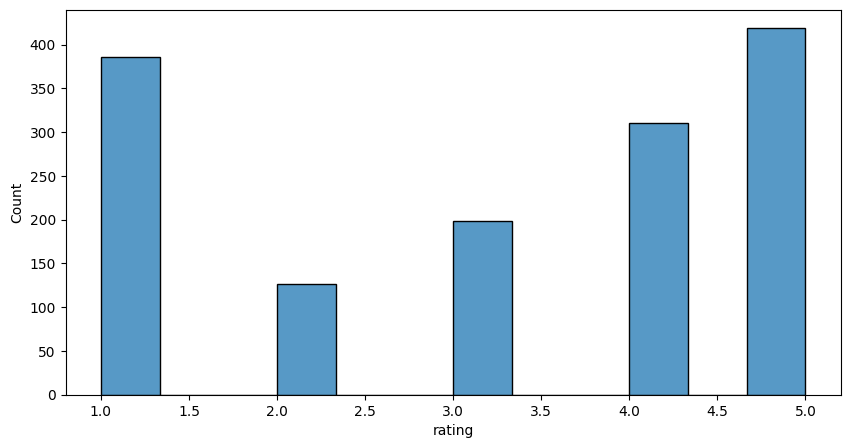

,count
rating,
5,419
1,386
4,310
3,199
2,126


In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['rating'])
plt.show()

df['rating'].value_counts()

In [ ]:
# --------------------------------------------------------------
# 1. INSTALL DEPENDENCIES (run once – will be skipped if already installed)
# --------------------------------------------------------------
!pip install -q deep_translator pandas nltk emoji openpyxl

# --------------------------------------------------------------
# 2. IMPORTS
# --------------------------------------------------------------
import pandas as pd
import re
import string
import emoji
import nltk

from deep_translator import GoogleTranslator
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# --------------------------------------------------------------
# 3. NLTK DATA DOWNLOAD (run once)
# --------------------------------------------------------------
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# --------------------------------------------------------------
# 4. TRANSLATION FUNCTION (kept exactly as you wrote it)
# --------------------------------------------------------------
def translate_text(text):
    try:
        result = GoogleTranslator(source='auto', target='en').translate(text)
        return result
    except Exception as e:
        return text

# --------------------------------------------------------------
# 5. TEXT CLEANING FUNCTION (kept exactly as you wrote it)
# --------------------------------------------------------------
def preprocess_text(text):
    if not isinstance(text, str):
        text = str(text)

    text = text.lower()

    # Remove URLs
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)

    # Remove @mentions and #hashtags
    text = re.sub(r'[@#]\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

# --------------------------------------------------------------
# 6. LOAD DATASET
# --------------------------------------------------------------
df = pd.read_excel('P597 DATASET.xlsx')

# --------------------------------------------------------------
# 7. PIPELINE: Translate → Clean
# --------------------------------------------------------------
print("Translating columns 'title' and 'body' …")
df['title'] = df['title'].apply(translate_text)
df['body']  = df['body'].apply(translate_text)

print("Cleaning translated text …")
df['title'] = df['title'].apply(preprocess_text)
df['body']  = df['body'].apply(preprocess_text)

# --------------------------------------------------------------
# 8. OPTIONAL: Save the processed DataFrame
# -------------------------------------------------------------
print("Done! Cleaned file saved as 'P597_DATASET.xlsx'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.8 MB/s eta 0:00:00
Translating columns 'title' and 'body' …
Cleaning translated text …
Done! Cleaned file saved as 'P597_DATASET.xlsx'


In [ ]:
df.head(20)

,title,rating,body
0,horrible product,1,disappointed overall performance samsung
1,camera quality like megapixel,3,camera quality low
2,overall,4,got mobile launch datebattery must appreciated...
3,big,1,doesnt work ghz wifi frequency ghz old school ...
4,put money somewhere else,1,worth buyingfaulty software poor display quali...
5,much lagging slow,1,never purchase samsung phone phone lagging muc...
6,worst samsung mobile ever,1,worst samsung mobile seen samsung sceen qualit...
7,even shown,1,camera mobile good pm clarity even mega pixel ...
8,slow performance,1,phone hang lot slow received replacement conti...
9,buy amazon,1,poor quality camera found box seal damage stil...


In [ ]:
df['title'][421]

'like samsung gb ram gb rom mh battery bought amazon'

In [ ]:
df.head(10)

,title,rating,body
0,horrible product,1,disappointed overall performance samsung
1,camera quality like megapixel,3,camera quality low
2,overall,4,got mobile launch datebattery must appreciated...
3,big,1,doesnt work ghz wifi frequency ghz old school ...
4,put money somewhere else,1,worth buyingfaulty software poor display quali...
5,much lagging slow,1,never purchase samsung phone phone lagging muc...
6,worst samsung mobile ever,1,worst samsung mobile seen samsung sceen qualit...
7,even shown,1,camera mobile good pm clarity even mega pixel ...
8,slow performance,1,phone hang lot slow received replacement conti...
9,buy amazon,1,poor quality camera found box seal damage stil...


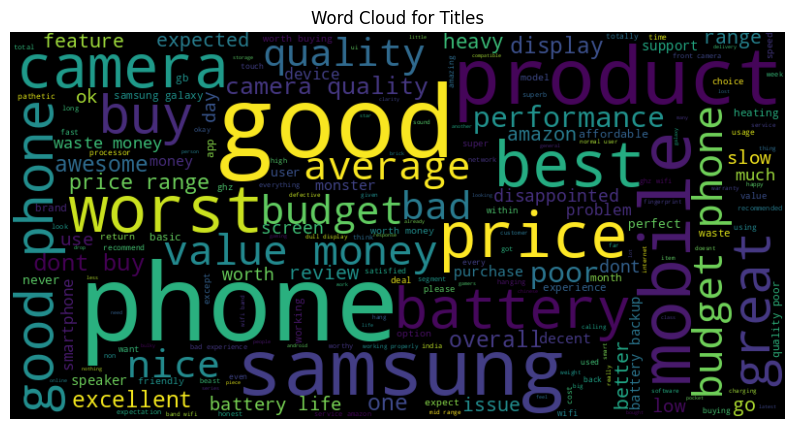

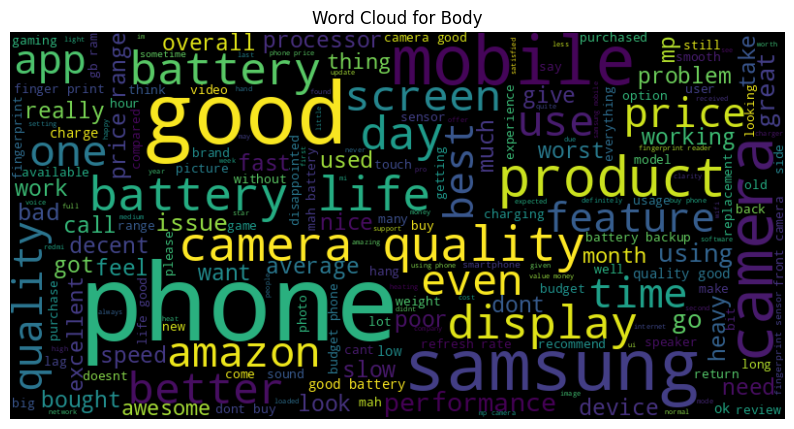

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wordcloud(text_column, title):
    """Generates and displays a word cloud for a given text column."""
    # Combine all text into a single string
    all_text = " ".join(text_column.dropna())

    # Create the word cloud object
    wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110).generate(all_text)

    # Display the word cloud
    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate word cloud for 'title'
generate_wordcloud(df['title'], 'Word Cloud for Titles')

# Generate word cloud for 'body'
generate_wordcloud(df['body'], 'Word Cloud for Body')

In [ ]:
def get_sentiment_from_rating(rating):

    if rating in [4, 5]:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    elif rating in [1, 2]:
        return "Negative"
    else:
        return "Unknown"


In [ ]:
df['sentiment'] = df['rating'].apply(get_sentiment_from_rating)
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)
df.head(20)

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64


,title,rating,body,sentiment
0,horrible product,1,disappointed overall performance samsung,Negative
1,camera quality like megapixel,3,camera quality low,Neutral
2,overall,4,got mobile launch datebattery must appreciated...,Positive
3,big,1,doesnt work ghz wifi frequency ghz old school ...,Negative
4,put money somewhere else,1,worth buyingfaulty software poor display quali...,Negative
5,much lagging slow,1,never purchase samsung phone phone lagging muc...,Negative
6,worst samsung mobile ever,1,worst samsung mobile seen samsung sceen qualit...,Negative
7,even shown,1,camera mobile good pm clarity even mega pixel ...,Negative
8,slow performance,1,phone hang lot slow received replacement conti...,Negative
9,buy amazon,1,poor quality camera found box seal damage stil...,Negative


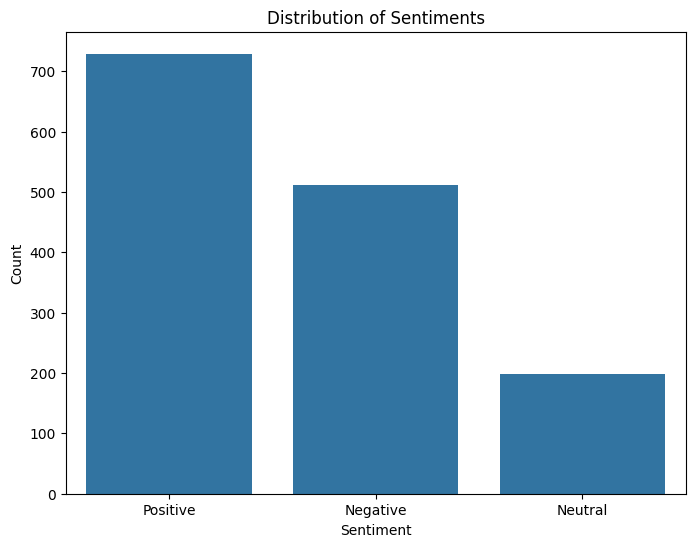

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [ ]:
%%writefile text_preprocessing.py
import re
import string
import emoji
import nltk
import pandas as pd

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from deep_translator import GoogleTranslator
from sklearn.base import BaseEstimator, TransformerMixin

# NLTK Data Download
def download_nltk_resources():
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('punkt_tab', quiet=True)

class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def translate_text(self, text):
        try:
            result = GoogleTranslator(source='auto', target='en').translate(text)
            return result
        except Exception as e:
            return text

    def preprocess_single_text(self, text):
        if not isinstance(text, str):
            text = str(text)

        text = text.lower()
        text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
        text = re.sub(r'[@#]\w+', '', text)
        text = re.sub(r'\d+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = emoji.replace_emoji(text, replace='')
        text = re.sub(r'\s+', ' ', text).strip()

        stop_words = set(stopwords.words('english'))
        lemmatizer = WordNetLemmatizer()

        tokens = word_tokenize(text)
        tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        return ' '.join(tokens)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.Series):
            return X.apply(self.preprocess_single_text)
        elif isinstance(X, pd.DataFrame):
            X_copy = X.copy()
            if 'title' in X_copy.columns:
                X_copy['title'] = X_copy['title'].apply(self.preprocess_single_text)
            if 'body' in X_copy.columns:
                X_copy['body'] = X_copy['body'].apply(self.preprocess_single_text)
            return X_copy
        else:
            raise TypeError("Expected pandas Series or DataFrame for transform method")

Writing text_preprocessing.py


# Feature Engineering

In [ ]:
from sklearn.model_selection import train_test_split
# Select the preprocessed 'title' and 'body' as features
X = df[['title', 'body']]
y = df['sentiment'] # Keep 'sentiment' as the target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")



Data split into training and testing sets:
Training features shape: (1152, 2)
Testing features shape: (288, 2)
Training target shape: (1152,)
Testing target shape: (288,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('title_tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=10000,
            sublinear_tf=True,
            min_df=2
        ), 'title'),

        ('body_tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=15000,
            sublinear_tf=True,
            min_df=2
        ), 'body')
    ],
    remainder='drop'
)

## Model Building and Evaluation

✔ Final Multilingual Pipeline Created Successfully
Training model with custom class weights...
✔ Training Complete!
Accuracy: 0.7638888888888888
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84       111
     Neutral       0.41      0.30      0.34        44
    Positive       0.79      0.86      0.82       133

    accuracy                           0.76       288
   macro avg       0.68      0.66      0.67       288
weighted avg       0.75      0.76      0.75       288



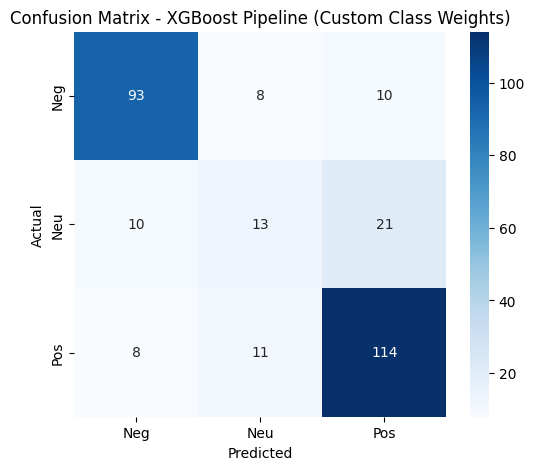

In [ ]:
# -----------------------------------------------
# 1. IMPORTS
# -----------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import xgboost as xgb
from text_preprocessing import TextPreprocessor
import numpy as np
import pandas as pd


# -----------------------------------------------
# 4. XGBoost Classifier
# -----------------------------------------------
xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    learning_rate=0.2,
    max_depth=6,
    n_estimators=250,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.3,
    reg_lambda=1.0,
    random_state=42
)

# -----------------------------------------------
# 5. FINAL PIPELINE
# -----------------------------------------------
pipeline_xgb_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_clf)
])

print("✔ Final Multilingual Pipeline Created Successfully")

# -----------------------------------------------
# 6. ENCODE TARGET & APPLY CLASS WEIGHTS
# -----------------------------------------------
sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
y_train_encoded = y_train.map(sentiment_mapping)
y_test_encoded = y_test.map(sentiment_mapping)

class_weights = {0: 2.0, 1: 10.0, 2: 1.0}
sample_weights = y_train_encoded.map(class_weights).values

# -----------------------------------------------
# 7. TRAIN PIPELINE
# -----------------------------------------------
print("Training model with custom class weights...")
pipeline_xgb_weighted.fit(X_train, y_train_encoded, classifier__sample_weight=sample_weights)
print("✔ Training Complete!")

# -----------------------------------------------
# 8. PREDICT & EVALUATE
# -----------------------------------------------
y_pred = pipeline_xgb_weighted.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print(classification_report(y_test_encoded, y_pred, target_names=['Negative','Neutral','Positive']))

# --- Step 8: Confusion Matrix for the Pipeline results ---
cm= confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
plt.title("Confusion Matrix - XGBoost Pipeline (Custom Class Weights)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Model Deployement

In [ ]:
import joblib
import os

# Assuming Logistic Regression is the chosen model for deployment based on current evaluation
# If you prefer a different model (e.g., the tuned XGBoost pipeline), please let me know.
best_model = pipeline_xgb_weighted

# Define the filename for the saved model
model_filename = 'sentiment_model.joblib'

# Save the model to a file
try:
    joblib.dump(best_model, model_filename)
    print(f"Model successfully saved to {model_filename}")

    # You can verify the file exists
    if os.path.exists(model_filename):
        print(f"File {model_filename} created successfully.")
except Exception as e:
    print(f"Error saving the model: {e}")

# --- Evaluation for Deployment ---
# Evaluating for deployment typically involves:
# 1. Loading the saved model.
# 2. Preprocessing new, unseen data in the same way as the training data.
# 3. Using the loaded model to make predictions on the new data.
# 4. Analyzing the predictions and potentially evaluating performance if ground truth is available.

print("\nTo evaluate the saved model for deployment:")
print(f"1. Load the model using: loaded_model = joblib.load('{model_filename}')")
print("2. Preprocess your new data using the same steps (translation, cleaning, vectorization).")
print("3. Make predictions on the preprocessed new data using: loaded_model.predict(new_data_features)")
print("4. Analyze the predictions.")

Model successfully saved to sentiment_model.joblib
File sentiment_model.joblib created successfully.

To evaluate the saved model for deployment:
1. Load the model using: loaded_model = joblib.load('sentiment_model.joblib')
2. Preprocess your new data using the same steps (translation, cleaning, vectorization).
3. Make predictions on the preprocessed new data using: loaded_model.predict(new_data_features)
4. Analyze the predictions.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import os
import logging

# Import the TextPreprocessor class and NLTK download function
from text_preprocessing import TextPreprocessor, download_nltk_resources

# -----------------------------
# Suppress Streamlit warnings
# -----------------------------
logging.getLogger("streamlit.runtime.scriptrunner.script_runner").setLevel(logging.ERROR)

# -----------------------------
# NLTK Data Download (required for preprocessing)
# -----------------------------
@st.cache_resource
def perform_nltk_downloads():
    download_nltk_resources()

perform_nltk_downloads()

# Initialize the TextPreprocessor outside the prediction block for efficiency
@st.cache_resource
def get_text_preprocessor():
    return TextPreprocessor()

text_preprocessor = get_text_preprocessor()

# -----------------------------
# Load the trained model
# -----------------------------
@st.cache_resource
def load_model():
    model_path = "sentiment_model.joblib"
    if not os.path.exists(model_path):
        st.error("❌ Model file not found. Please upload 'sentiment_model.joblib' first.")
        st.stop()
    return joblib.load(model_path)

model = load_model()

# -----------------------------
# Page setup
# -----------------------------
st.set_page_config(page_title="Sentiment Rating App", page_icon="💬", layout="centered")

st.title("💬 Sentiment Rating App (XGBoost + TF-IDF)")
st.markdown("""
Enter a **Title** and **Body** to predict sentiment.
The color bar fills **based on sentiment only**:
- 🔴 Negative (Red)
- 🟠 Neutral (Orange)
- 🟢 Positive (Green)
""")

st.divider()

# -----------------------------
# Input Section
# -----------------------------
title_input = st.text_input("📰 Enter Subject:")
body_input = st.text_area("📝 Enter Description:", height=180)

# -----------------------------
# Prediction Section
# -----------------------------
if st.button("🔍 Predict Sentiment"):
    if not title_input or not body_input:
        st.warning("⚠️ Please enter both Title and Body.")
    else:
        # Preprocess input using the TextPreprocessor instance
        # First translate, then preprocess (as per original notebook logic)
        translated_title = text_preprocessor.translate_text(title_input)
        translated_body = text_preprocessor.translate_text(body_input)

        processed_title = text_preprocessor.preprocess_single_text(translated_title)
        processed_body = text_preprocessor.preprocess_single_text(translated_body)

        # Prepare input DataFrame for the model
        input_df = pd.DataFrame({'title': [processed_title], 'body': [processed_body]})

        # Predict
        prediction = model.predict(input_df)[0]
        probabilities = model.predict_proba(input_df)[0] * 100

        sentiment_labels = {0: "Negative 😞", 1: "Neutral 😐", 2: "Positive 😊"}
        sentiment_text = sentiment_labels[prediction]
        confidence = probabilities[prediction]

        # -----------------------------
        # Fixed bar color and fill by sentiment
        # -----------------------------
        if prediction == 0:  # Negative
            fill_percent = 40
            bar_color = "#FF4B4B"  # Red
        elif prediction == 1:  # Neutral
            fill_percent = 75
            bar_color = "#FFA500"  # Orange
        else:  # Positive
            fill_percent = 100
            bar_color = "#4BB543"  # Green

        # -----------------------------
        # Display output
        # -----------------------------
        st.markdown(f"### 🎯 Predicted Sentiment: **{sentiment_text}**")
        st.markdown(f"**Model Confidence:** {confidence:.2f}%")

        # Sentiment-based color bar (no percentage text)
        bar_html = f"""
        <style>
        .bar-container {{
            background-color: #ddd;
            border-radius: 25px;
            width: 100%;
            height: 30px;
            margin-top: 10px;
        }}
        .bar-fill {{
            width: {fill_percent}%; /* Use fill_percent here */
            background-color: {bar_color};
            height: 30px;
            border-radius: 25px;
            transition: width 0.8s ease-in-out;
        }}
        </style>
        <div class='bar-container'>
            <div class='bar-fill'></div>
        </div>
        """
        st.markdown(bar_html, unsafe_allow_html=True)

        # -----------------------------
        # Show class probabilities
        # -----------------------------
        st.markdown("### 🧾 Class Probabilities")
        prob_df = pd.DataFrame({
            "Sentiment": ["Negative 😞", "Neutral 😐", "Positive 😊"],
            "Confidence (%)": probabilities.round(2)
        })
        st.dataframe(prob_df.set_index("Sentiment"))

# -----------------------------
# Sidebar Info
# -----------------------------
st.sidebar.title("ℹ️ App Info")
st.sidebar.write("""
**Sentiment Color Mapping (Fixed):**
- 🔴 Negative → Red (40%)
- 🟠 Neutral → Orange (75%)
- 🟢 Positive → Green (100%)

**Model:** XGBoost Classifier
**Features:** TF-IDF (Title + Body)
""")

Writing app.py


In [ ]:
!ls

 app.py		      __pycache__   sentiment_model.joblib
'P597 DATASET.xlsx'   sample_data   text_preprocessing.py


In [ ]:
!pip install streamlit pyngrok scikit-learn xgboost pandas numpy joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 81.1 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [ ]:
!ngrok authtoken "345l7kKMQnjJuqOYVU2XEZWbdE0_x2qdFethjWzpkXPG3PWj"


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

# Disconnect all existing tunnels
ngrok.kill()
print("✅ All existing ngrok tunnels have been closed.")


✅ All existing ngrok tunnels have been closed.


In [ ]:
import threading
import subprocess
from pyngrok import ngrok

def run_app():
    subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501"])

thread = threading.Thread(target=run_app)
thread.start()

public_url = ngrok.connect(addr=8501)
print("🎉 Your Streamlit app is live at:", public_url)


🎉 Your Streamlit app is live at: NgrokTunnel: "https://annalistically-unbeseeming-jazmine.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile requirements.txt
deep_translator==1.9.1
pandas==2.3.3
nltk
emoji
openpyxl==3.1.5
scikit-learn==1.6.1
xgboost==3.1.3
streamlit==1.54.0
numpy==2.2.6
joblib==1.5.3

Writing requirements.txt
